In [1]:
from earthkit import data as ekd
from earthkit import transforms as ekt
from earthkit import plots as ekp

In [2]:
%%capture
climdata = ekd.from_source(
    "cds",
    "derived-utci-historical",
    request = {
    "variable": ["tropical_nights_thermal_comfort_monthly_statistics"],
    "version": "1_1",
    "product_type": "consolidated_dataset",
    "year": [
        "1991", "1992", "1993",
        "1994", "1995", "1996",
        "1997", "1998", "1999",
        "2000", "2001", "2002",
        "2003", "2004", "2005",
        "2006", "2007", "2008",
        "2009", "2010", "2011",
        "2012", "2013", "2014",
        "2015", "2016", "2017",
        "2018", "2019", "2020"
    ],
    "month": ["06"]
}
)
climdata

In [3]:
%%capture
data = ekd.from_source(
    "cds",
    "derived-utci-historical",
    request = {
    "variable": ["tropical_nights_thermal_comfort_monthly_statistics"],
    "version": "1_1",
    "product_type": "intermediate_dataset",
    "year": ["2026"],
    "month": ["06"]
}
)
data

In [4]:
cds = climdata.to_xarray()

In [5]:
cds

<xarray.Dataset> Size: 125MB
Dimensions:                (time: 30, bnds: 2, lat: 721, lon: 1440)
Coordinates:
  * time                   (time) datetime64[ns] 240B 1991-06-15T23:30:00 ......
  * lat                    (lat) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * lon                    (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Dimensions without coordinates: bnds
Data variables:
    time_bnds              (time, bnds) datetime64[ns] 480B dask.array<chunksize=(1, 2), meta=np.ndarray>
    count_tropical_nights  (time, lat, lon) float32 125MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    frequency:    day
    history:      Fri Oct 03 18:52:00 2025: cdo -O -setname,count_tropical_ni...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [6]:
ds = data.to_xarray()

In [7]:
ds

<xarray.Dataset> Size: 4MB
Dimensions:                (time: 1, bnds: 2, lat: 721, lon: 1440)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2026-06-15T23:30:00
  * lat                    (lat) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * lon                    (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
Dimensions without coordinates: bnds
Data variables:
    time_bnds              (time, bnds) datetime64[ns] 16B ...
    count_tropical_nights  (time, lat, lon) float32 4MB ...
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    frequency:    day
    history:      Fri Jul 03 04:04:05 2026: cdo -O -setname,count_tropical_ni...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [8]:
climatology_mean = ekt.climatology.mean(cds)
anomaly = ekt.climatology.anomaly(ds, climatology_mean)

In [9]:
climatology_mean

<xarray.Dataset> Size: 4MB
Dimensions:                (bnds: 2, lon: 1440, lat: 721)
Coordinates:
  * lon                    (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * lat                    (lat) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds              (bnds) datetime64[ns] 16B dask.array<chunksize=(2,), meta=np.ndarray>
    count_tropical_nights  (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    frequency:    day
    history:      Fri Oct 03 18:52:00 2025: cdo -O -setname,count_tropical_ni...
    CDO:          Climate Data Operators version 2.4.0 (https://mpimet.mpg.de...

In [10]:
anomaly

<xarray.Dataset> Size: 4MB
Dimensions:                (time: 1, bnds: 2, lon: 1440, lat: 721)
Coordinates:
  * time                   (time) datetime64[ns] 8B 2026-06-15T23:30:00
  * lon                    (lon) float64 12kB -180.0 -179.8 ... 179.5 179.8
  * lat                    (lat) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds              (time, bnds) timedelta64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    count_tropical_nights  (time, lat, lon) float32 4MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    frequency:    day
    history:      Fri Jul 03 04:04:05 2026: cdo -O -setname,count_tropical_ni...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [11]:
tna = anomaly["count_tropical_nights"]

In [12]:
tna_domain = tna.sel(
    lon=slice(-11, 36),
    lat=slice(70, 30)   # latitude descending
)
print(tna_domain.min().compute())
print(tna_domain.max().compute())

<xarray.DataArray 'count_tropical_nights' ()> Size: 4B
array(-6.8999996, dtype=float32)
Attributes:
    code:          167
    table:         128
    cell_methods:  time: minimum
<xarray.DataArray 'count_tropical_nights' ()> Size: 4B
array(19.333332, dtype=float32)
Attributes:
    code:          167
    table:         128
    cell_methods:  time: minimum


In [13]:
caption = "Data: Thermal comfort indices derived from ERA5 reanalysis | Source: CDS\nDOI: 10.24381/cds.553b7518 | Created by: Bernadett Piros"

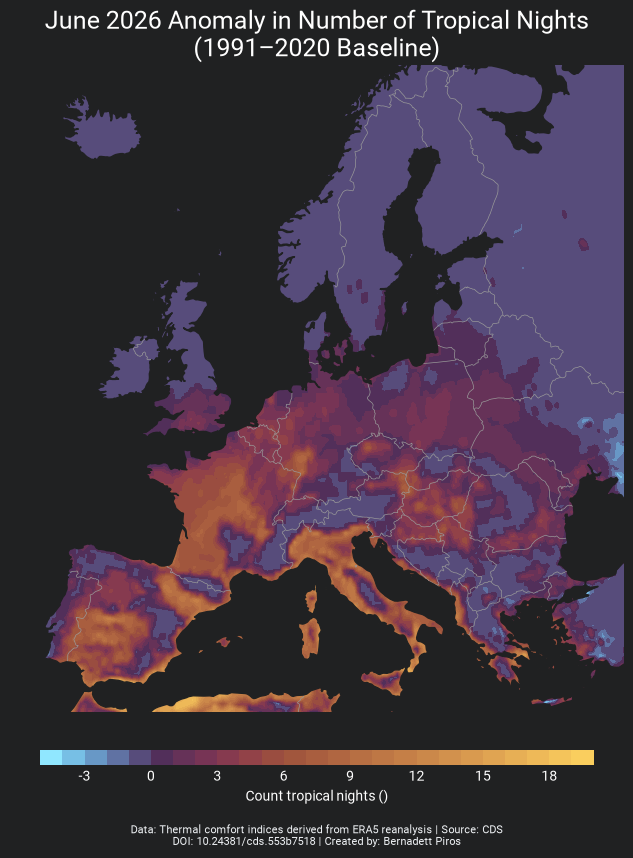

In [14]:
chart = ekp.Map(domain=(-11, 30, 36, 70))

chart.contourf(
    tna,
    colors=["#90e7ff", "#78c1e6", "#699bc9", "#6176a8", "#595282",
            "#4e2f5a",
            "#623159", "#733356", "#823851", "#8f3f4b", "#974843",
            "#9d533c", "#a55a3e", "#ac6240", "#b36a42", "#ba7244",
            "#c17a46", "#c78248", "#cd8a4b", "#d3934d", "#da9c4f",
            "#e1a652", "#e8b055", "#eeba58", "#f4c45b", "#face5e"        
    ], 
    levels={"step": 1, "reference": 0},
)

chart.ocean(color="#202122")
chart.borders()

chart.ax.spines["geo"].set_visible(False)

chart.fig.set_facecolor("#202122")

layer = chart.distinct_legend_layers[0]

cbar = layer._generate_legend(location="bottom")

cbar.ax.xaxis.label.set_color("white")
cbar.ax.tick_params(
    colors="white",
    labelcolor="white",
)

cbar.outline.set_visible(False)

cbar.ax.xaxis.label.set_text(
    cbar.ax.xaxis.label.get_text().capitalize())

chart.title("June 2026 Anomaly in Number of Tropical Nights\n(1991–2020 Baseline)", color="white", fontsize=18)

chart.fig.text(0.5, -0.05, s=caption, color="#EDF0F3", fontsize=8, ha="center")

chart.show()

#chart.save("tn_anomalies_june2026.png", dpi=300)